# Q13. Can better head convergence and gentler updates make Evo2 LoRA useful?

A one-hour experiment on the prepared H100: optimize a magnitude-aware linear classifier on verified frozen features, then compare two gentler LoRA settings against matched frozen controls. [Q12](Q12-lora-improvement.ipynb) found no adapter benefit; classifier improvement alone does not establish successful backbone adaptation.

Use **Gamow** and run every cell in order. Prerequisites are completed Q11/Q12 artifacts, the checksum-pinned Savanna Evo2 7B base checkpoint and the prepared BioNeMo runtime. [Protocol and reporting](src/q13.py) · [Head optimization](src/q13_heads.py) · [GPU workflow](src/q13_backend.py) · [Setup](../README.md#setup).

In [1]:
from src import q13

## Fixed inputs and feature provenance

Retain Q1’s frozen 6 July 2026 ClinVar missense partitions, all inherited eligibility and gene/component/sequence separation checks, and exactly Q12’s authorized **24,576 training variants** and uniform seed-42 **2,048 validation variants**. The full partitions contain 46,888 and 17,927 variants respectively. Validation remains a development set.

Reuse only checksum-verified Q12 frozen feature caches: 512-base canonical paired strand, final-block mean pooling, unit-RMS reference and allele-difference vectors, plus log difference RMS and log relative RMS (**8,194 features**). Retain Q12 training-only standardization. Freeze sources, parent results, cache manifest and exact memberships before fitting; validation labels never enter gradients or preprocessing.

In [2]:
protocol = q13.prepare()

Frozen 24,576/46,888 training rows and 2,048/17,927 validation rows; verified Q12 frozen features will be reused.


## Fit the head before adapting the backbone

Optimize a linear classifier using balanced training-subset binary cross entropy plus explicit L2 weight penalty (unpenalized intercept), with strengths **1e-4, 1e-3 and 1e-2**. Fit in FP64 for **1,000 iterations** followed by one continuation of up to **2,000 iterations** (**3,000 total**), requiring fitted full gradient norm **at most 1e-6**. Verify FP32 deployment logits and report the separate deployed gradient residual for every candidate. Exclude unconverged candidates; select by sampled AUROC, then AP, then stronger L2. This fitting stage runs again in a fresh notebook; the reused feature cache is a verified experimental input.

Initialize both adapter arms from the same selected fitted head, the original frozen backbone and zero-output rank-8/alpha-16 LoRA in the same block-30 projections as Q12. Try adapter peak learning rates **3e-5 and 1e-5**, with **32-step warmup** and cosine decay to **10%**. Head learning rate **1e-5**, adapter weight decay **0.01**, seed **42**, batch **32**, at most **512 updates per arm**. Keep BF16 backbone/adapters and FP32 head and optimizer master weights.

## Matched controls, stopping and integrity

Each arm has a cloned frozen-backbone head receiving the same examples, batch order, update count, class weights, explicit head L2 penalty and head schedule. Clip adapter and head gradient norms separately at **1.0**, using identical head clipping in the control. Record separate gradient norms and actual adapter/head weight and prediction changes. Retain **step 0**, then monitor after **256** and **512** updates, or when the deadline requires final validation and reporting. Save optimizer/master/RNG/cursor state every **32 updates**, with the original run deadline recorded. These states are retained for inspection; automatic checkpoint resumption is not implemented. A fresh runner archives the preceding attempt and starts a new experiment from zero-output adapters.

Use one GPU process. Reserve a sampled evaluation, a **64-variant** checkpoint reload check and three minutes for reporting under the one-hour budget; interrupted and completed attempts remain inspectable. Verify finite updates and unchanged original backbone tensors. Erase learned tensors and reload the selected checkpoint to reproduce predictions.

Choose LoRA only when it improves AUROC by **at least 0.005** without decreasing AP against the strongest frozen classifier, including Q12’s control and the initial fitted head. Retain the best LoRA checkpoint together with the control at its exact update count for paired inference. A gain from classifier fitting is reported separately.

In [3]:
result = q13.run_experiment()

Explore: notebooks/results/q13/explore.log


## Sampled development results

Report AUROC/AP with **1,000 whole-component bootstrap draws**, seed **42**, and the paired LoRA-minus-control effect. Intervals do not correct repeated validation, regularization, learning-rate or checkpoint selection. These results cannot establish performance on an untouched holdout and must stay separate from the full-cohort README benchmark.

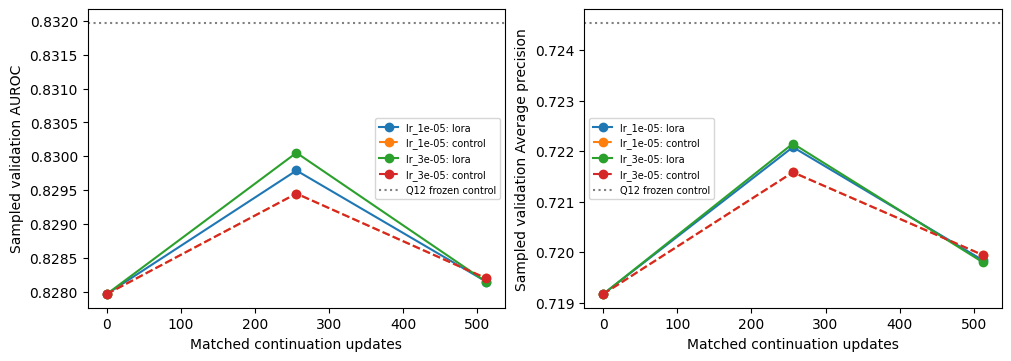

| Model | AUROC (95% interval) | AP (95% interval) |
| --- | ---: | ---: |
| Q12 frozen control | 0.832 [0.812, 0.853] | 0.725 [0.681, 0.771] |
| Matched frozen control | 0.829 [0.808, 0.850] | 0.722 [0.676, 0.766] |
| Best Q13 frozen control | 0.829 [0.808, 0.850] | 0.722 [0.676, 0.766] |
| Best Q13 LoRA | 0.830 [0.809, 0.851] | 0.722 [0.677, 0.767] |
| Selected model | 0.832 [0.812, 0.853] | 0.725 [0.681, 0.771] |

In [4]:
q13.show_results()

## Conclusion

The conclusion is computed from the completed run and its frozen promotion rule.

In [5]:
q13.show_conclusion()

**Conclusion.** LoRA did not meet the prespecified promotion rule; retain the strongest frozen classifier. Selected **q12_control**: AUROC **0.832**, AP **0.725**, on **2,048 development validation variants**. Best adapter trial: **lr_3e-05**, checkpoint **256 updates**. LoRA minus its matched control: AUROC **+0.0006** (95% component interval **[-0.0003, +0.0016]**). Promotion requires at least **0.005 AUROC** improvement and no AP reduction against the strongest Q13 or Q12 frozen control, including the initial fitted head. The measured experiment took **41.2 minutes**; within the one-hour target. These sampled results do not replace the complete-cohort benchmark. User-authorized exploratory subsets: the same 24,576 training variants and 2,048 validation variants as Q12. Validation selects regularization, adapter learning rate and checkpoints; repeated development selection and bootstrap intervals do not establish performance on an untouched holdout. The paired effect compares LoRA with its control after the same examples and update count; promotion also requires improvement over the strongest current or Q12 frozen control. No clinical validation; pretraining exposure, homology and shared-patient overlap remain unresolved.